In [1]:
import os

GPU_NUM = 1
GPU_NUM = str(GPU_NUM)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_NUM 

# torch를 CUDA_VISIBLE_DEVICES 뒤에 import 해야 제대로 설정됨.
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'CUDA Device Name: {torch.cuda.get_device_name(0)}, GPU NUM: {GPU_NUM}')
else: print(device)

torch.cuda.empty_cache() 

cpu


In [2]:
import warnings
warnings.filterwarnings('ignore')

import h5py
import scipy
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.signal import hilbert
from dataclasses import dataclass
from matplotlib.animation import FuncAnimation

import torch
import torch.nn.functional as F

In [3]:
from utils.utils import *

In [4]:
def resample_cols(x, W_p):
    B, C, D, W = x.shape

    x = x.permute(0, 2, 1, 3).reshape(B * D, C, W)  # (B*D, C, W)
    x = F.interpolate(x, size=W_p, mode='linear', align_corners=False)
    x = x.reshape(B, D, C, W_p).permute(0, 2, 1, 3) # (B, C, D, W_p)

    return x

In [5]:
class DAS():
    def __init__(self, H_p: int=374, W_p: int=128, N: int=128, H_m: float=0.038, W_m: float=0.038,
                 sos: float=1540., freq: float=7.6e6, sampling: float=4.1118):
        self.N      = N
        self.H_p    = H_p
        self.W_p    = W_p
        self.H_m    = H_m
        self.W_m    = W_m
        self.sos    = sos
        self.freq   = freq
        self.sampling = sampling

        # Scale factors
        self.p2m_H  = H_m / H_p
        self.p2m_W  = W_m / W_p
        self.m2l    = freq / sos
        self.l2s    = sampling

        x = torch.arange(H_p).view(-1, 1, 1) * self.p2m_H   # (H_p, 1, 1)
        y = torch.arange(W_p).view(1, -1, 1) * self.p2m_W   # (1, W_p, 1)
        n = torch.arange(N).view(1, 1, -1) * self.p2m_W     # (1, 1, N)

        M1 = x * (self.m2l * self.l2s)                              # (H_p, 1, 1)
        M2 = torch.sqrt((y - n)**2 + x**2) * (self.m2l * self.l2s)  # (H_p, W_p, N)
        M  = M1 + M2                                                # (H_p, W_p, N)

        self.M1 = torch.round(M1).long()
        self.M2 = torch.round(M2).long()
        self.M  = torch.round(M).long()
        print(f'{"Indexing Matrix":<25}: {self.M.shape}')

        self.idx_x = torch.arange(H_p).long()
        self.idx_y = torch.arange(W_p).long()
        self.idx_n = torch.arange(N).long()

        # Resampler
        if W_p != 128:
            self.resampler = resample_cols
            self.W_p = W_p
        
        else:
            self.resampler = None

        # Dynami Aperture
        list_sigma  = torch.linspace(0.01, 1, H_p)**0.3
        list_sigma  = list_sigma * 5 + 1
        list_s      = [-s for s in range(0, N)]

        x = torch.stack([torch.linspace(s, s + N - 1, N) for s in list_s])
        self.mask_DA = torch.stack([torch.exp(-0.5 * (x / sigma)**2) for sigma in list_sigma]).unsqueeze(0).unsqueeze(0) # (1, 1, H_p, N, N)

    def delay_and_sum(self, 
                        RF: torch.Tensor | np.ndarray,
                        Ne: int | None=None,
                        Nf: int | None=None,
                        ensemble: bool=True, PA: bool=False, DA: bool=True):
        
        if not isinstance(RF, torch.Tensor):
            RF = torch.tensor(RF, dtype=torch.float32)
        
        elif RF.dtype != torch.float32:
            RF = RF.to(dtype=torch.float32)

        if self.resampler is not None:
            print(f'{"Resampling RF Columns":<25}: {RF.shape[-1]} -> {self.W_p}')
            RF = self.resampler(RF, self.W_p)

        print(f'{"RF(Raw)":<25}: {RF.shape}')
        if Ne is not None:
            RF = RF[Ne, :, :, :]
        
        if Nf is not None:
            RF = RF[:, Nf, :, :]
        print(f'{"RF(Target)":<25}: {RF.shape}')
        
        # Index clamping
        M_idx   = self.M2 if PA else self.M
        M_idx   = M_idx.clamp(0, RF.shape[-2] - 1)

        RF_res  = RF[:, :, M_idx, self.idx_n]
        print(f'{"Extracted":<25}: {RF_res.shape}')

        if DA is not False:
            RF_res = RF_res * self.mask_DA.to(RF_res.device)
            print(f'{"Dynamic Aperture mask":<25}: {self.mask_DA.shape}')

        RF_res = RF_res.sum(dim=-1).float()
        print(f'{"RF Result":<25}: {RF_res.shape}')

        if ensemble is not False:
            RF_res = RF_res.mean(dim=0)
            print(f'{"RF Result(AGG)":<25}: {RF_res.shape}')
        
        print('--' * 25)

        return RF_res

In [6]:
@dataclass
class Config:
    H: int = 256
    W: int = 256
    N: int = 256
    
    an: int = 31
    depth:  float = 0.038
    width:  float = 0.038
    p2m_H:  float = depth / H
    p2m_W:  float = width / W
    m2l:    float = 7.6e6 / 1540.
    l2s:    float = 4.1118

    def __repr__(self):
        items = [f"    {k:<10}: {v}" for k, v in self.__dict__.items()]
        return f"{'-'*15} Config {'-'*15}\n\n" + ",\n".join(items)

cfg = Config()
print(cfg)

--------------- Config ---------------

    H         : 256,
    W         : 256,
    N         : 256,
    an        : 31,
    depth     : 0.038,
    width     : 0.038,
    p2m_H     : 0.0001484375,
    p2m_W     : 0.0001484375,
    m2l       : 4935.064935064935,
    l2s       : 4.1118


In [7]:
DATASET_PATH = Path('/nas/Guhong/US_Data/Dataset/Dataset_USRecon')
print(f'Data Path: {DATASET_PATH}\n')

DATA_LIST = listdir(DATASET_PATH)
print(f'Data Folders: {len(DATA_LIST)} folders found')
for folder in DATA_LIST:
    folder_path = DATASET_PATH / folder
    file_count = len(list(folder_path.glob('*')))
    print(f"- {folder}: {file_count} files")

Data Path: /nas/Guhong/US_Data/Dataset/Dataset_USRecon

Data Folders: 10 folders found
- Patient_001: 220 files
- Patient_002: 220 files
- Patient_003: 220 files
- Patient_004: 220 files
- Patient_005: 220 files
- Patient_006: 220 files
- Patient_007: 220 files
- Patient_008: 220 files
- Patient_009: 220 files
- Patient_010: 220 files


In [8]:
print(f'{"Sample Data":<20}: {DATA_LIST[0]}')

DATA_PATH = DATASET_PATH / DATA_LIST[0]
print(f'{"Sample Data Path":<20}: {DATA_PATH}')

RF_LIST = list(DATA_PATH.glob('*an31_F_*'))

PB_LIST = list(DATA_PATH.glob('*an31_B_*'))

RB_LIST = list(DATA_PATH.glob('*an31_R_*'))

Sample Data         : Patient_001
Sample Data Path    : /nas/Guhong/US_Data/Dataset/Dataset_USRecon/Patient_001


In [9]:
PB_DATA = h5py.File(PB_LIST[0], 'r')
print(f'PB Data Keys: {list(PB_DATA.keys())}')
PB = PB_DATA['imgs'][:]
print(f'PB Shape: {PB.shape}')

RB_DATA = h5py.File(RB_LIST[0], 'r')
print(f'\nRB Data Keys: {list(RB_DATA.keys())}')
RB = RB_DATA['imgs'][:]
print(f'RB Shape: {RB.shape}')

RF_DATA = h5py.File(RF_LIST[0], 'r')
print(f'\nRF Data Keys: {list(RF_DATA.keys())}')

RF_O    = torch.tensor(RF_DATA['imgs'][:], dtype=torch.float32)
B, T, C = RF_O.shape
RF_B    = RF_O.reshape(cfg.an, B, T // cfg.an, C)
print(f'RF Shape: {RF_O.shape} -> {RF_B.shape}')
print(f'RF Min: {RF_B.min():.4f}, Max: {RF_B.max():.4f}, Mean: {RF_B.mean():.4f}, Std: {RF_B.std():.4f}')

PB Data Keys: ['imgs']
PB Shape: (190, 256, 256)

RB Data Keys: ['imgs']
RB Shape: (190, 256, 256)

RF Data Keys: ['imgs']
RF Shape: torch.Size([190, 71424, 128]) -> torch.Size([31, 190, 2304, 128])
RF Min: -16384.0000, Max: 16384.0000, Mean: 0.2376, Std: 2139.8757


In [10]:
SAMPLE_DATA = scipy.io.loadmat('data_sample.mat')
print(f'\nSample Data Keys: {list(SAMPLE_DATA.keys())}')

SAMPLE_RF = SAMPLE_DATA['RF_data']
print(f'\nSample Data Shape: {SAMPLE_RF.shape}')


Sample Data Keys: ['__header__', '__version__', '__globals__', 'RF_data']

Sample Data Shape: (1, 100, 2176, 128)


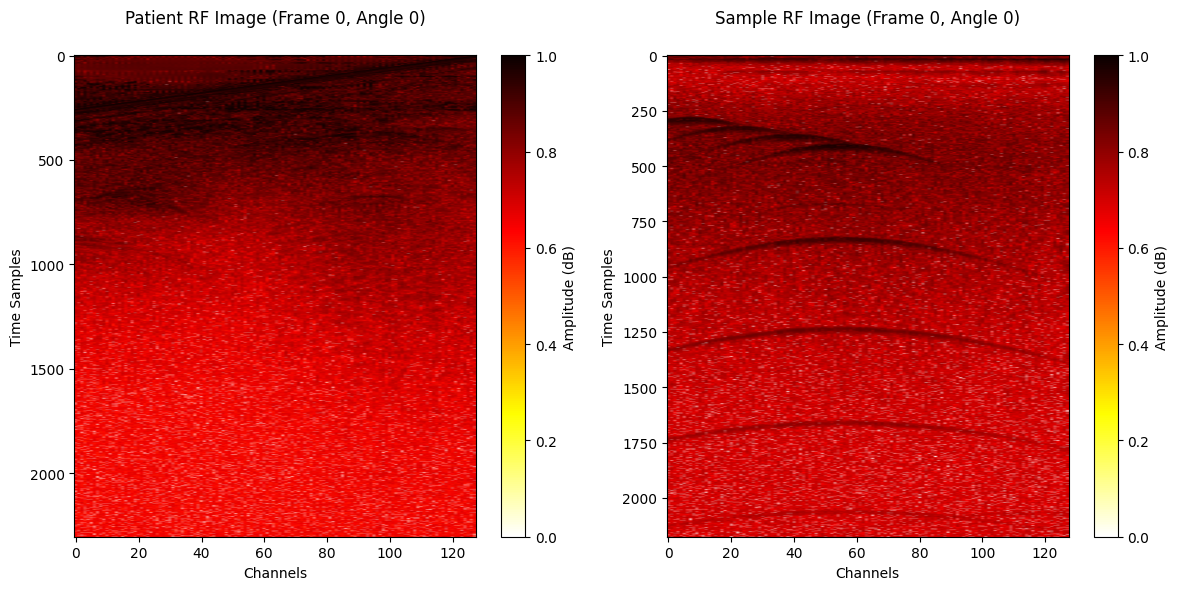

In [72]:
frame = 0
angle = 0
rf_img = RF_B[0, frame]
rf_img = np.abs(rf_img)
rf_img = 20 * np.log10(rf_img + 1e-6)
rf_img = (rf_img - rf_img.min()) / (rf_img.max() - rf_img.min())

sf_img = SAMPLE_RF[angle, frame]
sf_img = np.abs(sf_img)
sf_img = 20 * np.log10(sf_img + 1e-6)
sf_img = (sf_img - sf_img.min()) / (sf_img.max() - sf_img.min())

imgs = [rf_img, sf_img]
titles = ['Patient RF Image', 'Sample RF Image']

plt.figure(figsize=(12, 6))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i + 1)
    plt.imshow(img, cmap='hot_r', aspect='auto')
    plt.title(f'{titles[i]} (Frame {frame}, Angle {angle})', y=1.05)
    plt.xlabel('Channels')
    plt.ylabel('Time Samples')
    plt.colorbar(label='Amplitude (dB)')

plt.tight_layout()
plt.show()

# plt.figure(figsize=(4, 6))
# plt.imshow(rf_img, cmap='hot_r', aspect='auto')
# plt.title(f'Raw RF Data (Frame {frame}, Angle {angle})', y=1.05)
# plt.xlabel('Channels')
# plt.ylabel('Time Samples')
# plt.colorbar(label='Amplitude (dB)')
# plt.tight_layout()
# plt.show()

Indexing Matrix          : torch.Size([256, 256, 256])
Resampling RF Columns    : 128 -> 256
RF(Raw)                  : torch.Size([1, 1, 2176, 256])
RF(Target)               : torch.Size([1, 1, 2176, 256])
Extracted                : torch.Size([1, 1, 256, 256, 256])
Dynamic Aperture mask    : torch.Size([1, 1, 256, 256, 256])
RF Result                : torch.Size([1, 1, 256, 256])
RF Result(AGG)           : torch.Size([1, 256, 256])
--------------------------------------------------


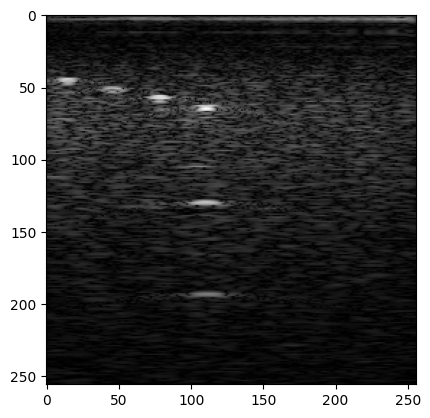

In [80]:
das = DAS(H_p=256, W_p=256, N=256, sos=1450)

frame = 50
res = das.delay_and_sum(SAMPLE_RF[:1, frame:frame+1, :, :])
res = 20*torch.log10(torch.abs(res)+1)
res = res/res.max()
plt.imshow(res[0]**3, 'gray'); plt.show()

Indexing Matrix          : torch.Size([256, 256, 256])
Resampling RF Columns    : 128 -> 256
RF(Raw)                  : torch.Size([1, 1, 2304, 256])
RF(Target)               : torch.Size([1, 1, 2304, 256])
Extracted                : torch.Size([1, 1, 256, 256, 256])
RF Result                : torch.Size([1, 1, 256, 256])
RF Result(AGG)           : torch.Size([1, 256, 256])
--------------------------------------------------


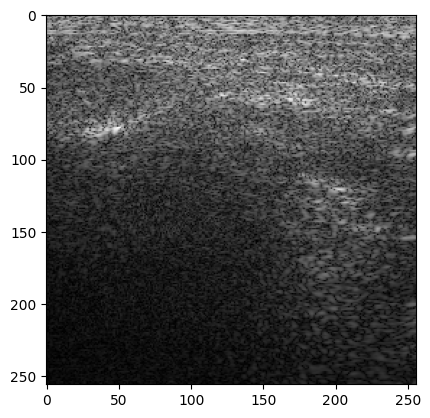

In [95]:
das = DAS(H_p=256, W_p=256, N=256, freq=7.6e+6)

frame = 50
res = das.delay_and_sum(RF_B[:1, frame:frame+1, :, :], DA=False)
res = 20*torch.log10(torch.abs(res)+1)
res = res/res.max()
plt.imshow(res[0]**3, 'gray')

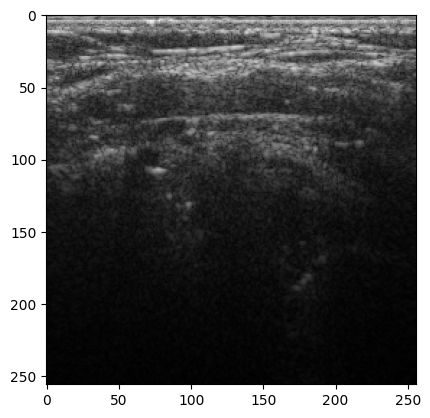

In [82]:
plt.imshow(PB[50], 'gray')